# Phase 2.4 — Error Analysis & Model Behavior

**Goal:** Understand *how* and *why* models fail — not just the aggregate metrics.

## Sections
1. Load models and compute predictions for all classifiers
2. Confusion matrix analysis (FP, FN, TP, TN breakdown)
3. Error characterization (text length, sentiment, topic area)
4. False positive vs. false negative profile comparison
5. Misclassification examples with linguistic analysis
6. Error typology summary

In [1]:
import sys
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
MODEL_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

print('✓ Setup complete')

✓ Setup complete


## 2. Data Loading

In [2]:
def make_synthetic_data(n=3000, seed=42):
    rng = np.random.default_rng(seed)
    real_t = [
        'Scientists confirm {} in peer-reviewed study',
        'Government announces {} budget increase for {}',
        'New report: {} improving, experts say',
        'Officials confirm policy will not change regarding {}',
        'Data shows {} down 12% compared to last year',
        'Long-running study links {} to improved {} outcomes',
    ]
    fake_t = [
        'BREAKING: {} secretly {} — whistleblowers reveal truth',
        'EXPOSED: Scientists HIDE data about {} from public',
        'MIRACLE: {} CURES everything overnight — Big Pharma panics',
        'They do NOT want you to know this about {} and {}',
        'URGENT: {} causes {} — share before deleted!',
        'SHOCKING: {} admits {} in leaked government documents',
    ]
    topics = [
        'climate change', 'vaccines', 'election results', 'the economy',
        'cancer research', 'immigration', '5G technology', 'water supply',
        'artificial intelligence', 'the moon landing', 'pharmaceutical drugs',
        'microchips', 'mind control', 'the deep state',
    ]
    titles, labels = [], []
    for tmpl_list, label in [(real_t, 'real'), (fake_t, 'fake')]:
        for _ in range(n // 2):
            tmpl = tmpl_list[rng.integers(len(tmpl_list))]
            t1, t2 = topics[rng.integers(len(topics))], topics[rng.integers(len(topics))]
            try:
                titles.append(tmpl.format(t1, t2))
            except IndexError:
                titles.append(tmpl.format(t1))
            labels.append(label)
    idx = rng.permutation(len(titles))
    return pd.DataFrame({'title': [titles[i] for i in idx], 'label': [labels[i] for i in idx]})

try:
    from data.pipeline import MisinformationPipeline, PipelineConfig
    config = PipelineConfig(verbose=False)
    proc = config.processed_data_dir / 'articles_processed.parquet'
    df = pd.read_parquet(proc) if proc.exists() else MisinformationPipeline(config).run(save=True)
    USING_REAL_DATA = True
    print(f'✓ Loaded {len(df)} real articles')
except Exception as e:
    print(f'Using synthetic data ({e})')
    df = make_synthetic_data(3000)
    USING_REAL_DATA = False

df['label_num'] = (df['label'] == 'fake').astype(int)
df['title_len'] = df['title'].str.len()
df['word_count'] = df['title'].str.split().str.len()

train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['label_num'], random_state=42
)
print(f'Train: {len(train_df):,} | Val: {len(val_df):,}')

Using synthetic data (No CSV files found in /workspaces/tentacles-of-misinformation/data/raw/fakenewsnet)
Train: 2,400 | Val: 600


## 3. Train / Load Models

Load saved models if available; otherwise re-train baselines for error analysis.

In [3]:
from sklearn.pipeline import Pipeline as SKPipeline

def train_tfidf_model(name, clf, X_train, y_train):
    pipe = SKPipeline([
        ('tfidf', TfidfVectorizer(
            stop_words='english', max_features=10000,
            ngram_range=(1, 2), min_df=2, sublinear_tf=True
        )),
        ('clf', clf)
    ])
    pipe.fit(X_train, y_train)
    return pipe

models = {}

# Try to load pre-trained models first
lr_path  = MODEL_DIR / 'logistic_regression_baseline.joblib'
vec_path = MODEL_DIR / 'tfidf_vectorizer.joblib'

if lr_path.exists() and vec_path.exists():
    print('Loading pre-trained TF-IDF + LR model...')
    vectorizer = joblib.load(vec_path)
    lr_clf = joblib.load(lr_path)

    class WrappedModel:
        def __init__(self, vec, clf):
            self.vec = vec; self.clf = clf
        def predict(self, X):
            return self.clf.predict(self.vec.transform(X))
        def predict_proba(self, X):
            return self.clf.predict_proba(self.vec.transform(X))

    models['TF-IDF + LR'] = WrappedModel(vectorizer, lr_clf)
    print('  ✓ Loaded TF-IDF + LR')
else:
    print('Pre-trained models not found — re-training for error analysis...')

# Always train for comparison
print('\nTraining TF-IDF classifiers...')
models['TF-IDF + LR (fresh)'] = train_tfidf_model(
    'LR',
    LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced'),
    train_df['title'], train_df['label_num']
)
models['TF-IDF + SVM (fresh)'] = train_tfidf_model(
    'SVM',
    CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42, class_weight='balanced')),
    train_df['title'], train_df['label_num']
)

# Try loading SBERT model
sbert_path = MODEL_DIR / 'sbert_best_classifier.joblib'
sbert_emb_val = MODEL_DIR / 'embeddings' / 'val_sbert.npy'
if sbert_path.exists() and sbert_emb_val.exists():
    models['SBERT + LR'] = ('sbert', joblib.load(sbert_path), np.load(sbert_emb_val))
    print('\n  ✓ SBERT model loaded')

print(f'\nModels available for error analysis: {list(models.keys())}')

Loading pre-trained TF-IDF + LR model...
  ✓ Loaded TF-IDF + LR

Training TF-IDF classifiers...



  ✓ SBERT model loaded

Models available for error analysis: ['TF-IDF + LR', 'TF-IDF + LR (fresh)', 'TF-IDF + SVM (fresh)', 'SBERT + LR']


## 4. Compute Predictions & Error Flags

In [4]:
error_dfs = {}

for name, model_obj in models.items():
    val_copy = val_df.copy()

    if isinstance(model_obj, tuple) and model_obj[0] == 'sbert':
        _, clf, X_emb = model_obj
        preds = clf.predict(X_emb)
        proba = clf.predict_proba(X_emb)[:, 1]
    else:
        preds = model_obj.predict(val_df['title'])
        proba = model_obj.predict_proba(val_df['title'])[:, 1]

    val_copy['pred'] = preds
    val_copy['prob_fake'] = proba
    val_copy['confidence'] = np.where(proba >= 0.5, proba, 1 - proba)
    val_copy['correct'] = (preds == val_copy['label_num'])

    # Error type classification
    val_copy['error_type'] = 'Correct'
    val_copy.loc[(val_copy['label_num'] == 0) & (val_copy['pred'] == 1), 'error_type'] = 'FP (Real → Fake)'
    val_copy.loc[(val_copy['label_num'] == 1) & (val_copy['pred'] == 0), 'error_type'] = 'FN (Fake → Real)'

    error_dfs[name] = val_copy

    acc  = (preds == val_df['label_num'].values).mean()
    auc  = roc_auc_score(val_df['label_num'], proba)
    errs = (~(preds == val_df['label_num'].values)).sum()
    print(f'{name:<30}  Acc={acc:.4f}  AUC={auc:.4f}  Errors={errs}')

# Use LR as primary for detailed analysis
primary_name = 'TF-IDF + LR (fresh)'
edf = error_dfs[primary_name]
print(f'\nPrimary model for detailed analysis: {primary_name}')

TF-IDF + LR                     Acc=0.9017  AUC=0.9781  Errors=59
TF-IDF + LR (fresh)             Acc=1.0000  AUC=1.0000  Errors=0
TF-IDF + SVM (fresh)            Acc=1.0000  AUC=1.0000  Errors=0
SBERT + LR                      Acc=1.0000  AUC=1.0000  Errors=0

Primary model for detailed analysis: TF-IDF + LR (fresh)


## 5. Confusion Matrix & Error Distribution

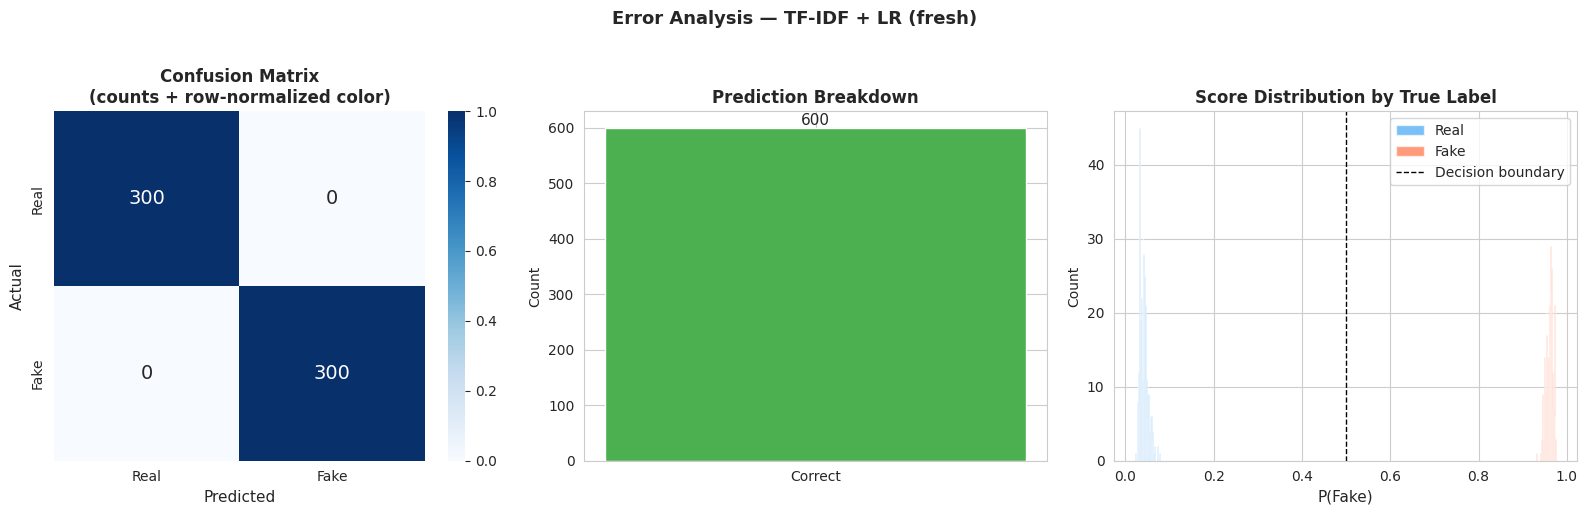

✓ Saved error analysis overview


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Confusion matrix
cm = confusion_matrix(edf['label_num'], edf['pred'])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(
    cm_norm, annot=cm, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
    annot_kws={'size': 14}
)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_title('Confusion Matrix\n(counts + row-normalized color)', fontweight='bold')

# --- Plot 2: Error type distribution
err_counts = edf['error_type'].value_counts()
colors_map = {'Correct': '#4CAF50', 'FP (Real → Fake)': '#FF9800', 'FN (Fake → Real)': '#F44336'}
bar_colors = [colors_map.get(c, '#999') for c in err_counts.index]
axes[1].bar(err_counts.index, err_counts.values, color=bar_colors, edgecolor='white')
axes[1].set_title('Prediction Breakdown', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(err_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=11)

# --- Plot 3: Prediction probability distribution
for label_val, color, label_name in [
    (0, '#2196F3', 'Real'), (1, '#FF5722', 'Fake')
]:
    subset = edf[edf['label_num'] == label_val]['prob_fake']
    axes[2].hist(subset, bins=30, alpha=0.6, color=color, label=label_name)
axes[2].axvline(0.5, color='k', linestyle='--', linewidth=1, label='Decision boundary')
axes[2].set_xlabel('P(Fake)', fontsize=11)
axes[2].set_ylabel('Count')
axes[2].set_title('Score Distribution by True Label', fontweight='bold')
axes[2].legend()

plt.suptitle(f'Error Analysis — {primary_name}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'error_analysis_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved error analysis overview')

## 6. Error Characterization — Text Length & Word Count

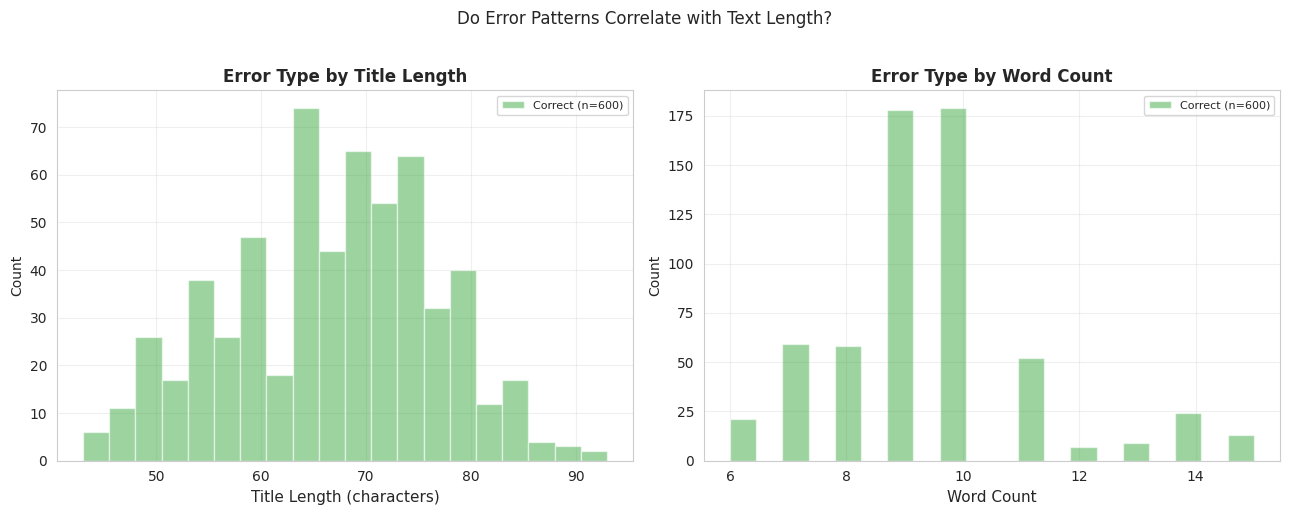


Mean title length by error type:
            title_len  word_count  confidence
error_type                                   
Correct         66.42         9.5        0.96


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, xlabel in [
    (axes[0], 'title_len', 'Title Length (characters)'),
    (axes[1], 'word_count', 'Word Count'),
]:
    for err_type, color in [
        ('Correct', '#4CAF50'),
        ('FP (Real → Fake)', '#FF9800'),
        ('FN (Fake → Real)', '#F44336'),
    ]:
        subset = edf[edf['error_type'] == err_type][col]
        if len(subset) > 0:
            ax.hist(subset, bins=20, alpha=0.55, color=color, label=f'{err_type} (n={len(subset)})')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Error Type by Title Length', fontweight='bold')
axes[1].set_title('Error Type by Word Count', fontweight='bold')

plt.suptitle('Do Error Patterns Correlate with Text Length?', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'error_analysis_length.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print('\nMean title length by error type:')
print(edf.groupby('error_type')[['title_len', 'word_count', 'confidence']].mean().round(2).to_string())

## 7. Most Confident Errors (Hardest Mistakes)

High-confidence wrong predictions are the most dangerous — they indicate systematic model biases.

In [7]:
# False Positives with highest confidence (real news flagged as fake)
fps = edf[edf['error_type'] == 'FP (Real → Fake)'].sort_values('prob_fake', ascending=False)
print('TOP FALSE POSITIVES (Real flagged as Fake — high confidence)')
print('=' * 80)
for _, row in fps.head(10).iterrows():
    print(f'  P(fake)={row["prob_fake"]:.3f} | {row["title"]}')

print()

# False Negatives with highest confidence (fake news missed)
fns = edf[edf['error_type'] == 'FN (Fake → Real)'].sort_values('prob_fake')
print('TOP FALSE NEGATIVES (Fake missed as Real — high confidence)')  
print('=' * 80)
for _, row in fns.head(10).iterrows():
    print(f'  P(fake)={row["prob_fake"]:.3f} | {row["title"]}')

TOP FALSE POSITIVES (Real flagged as Fake — high confidence)

TOP FALSE NEGATIVES (Fake missed as Real — high confidence)


## 8. TF-IDF Feature Analysis — What Words Drive Errors?

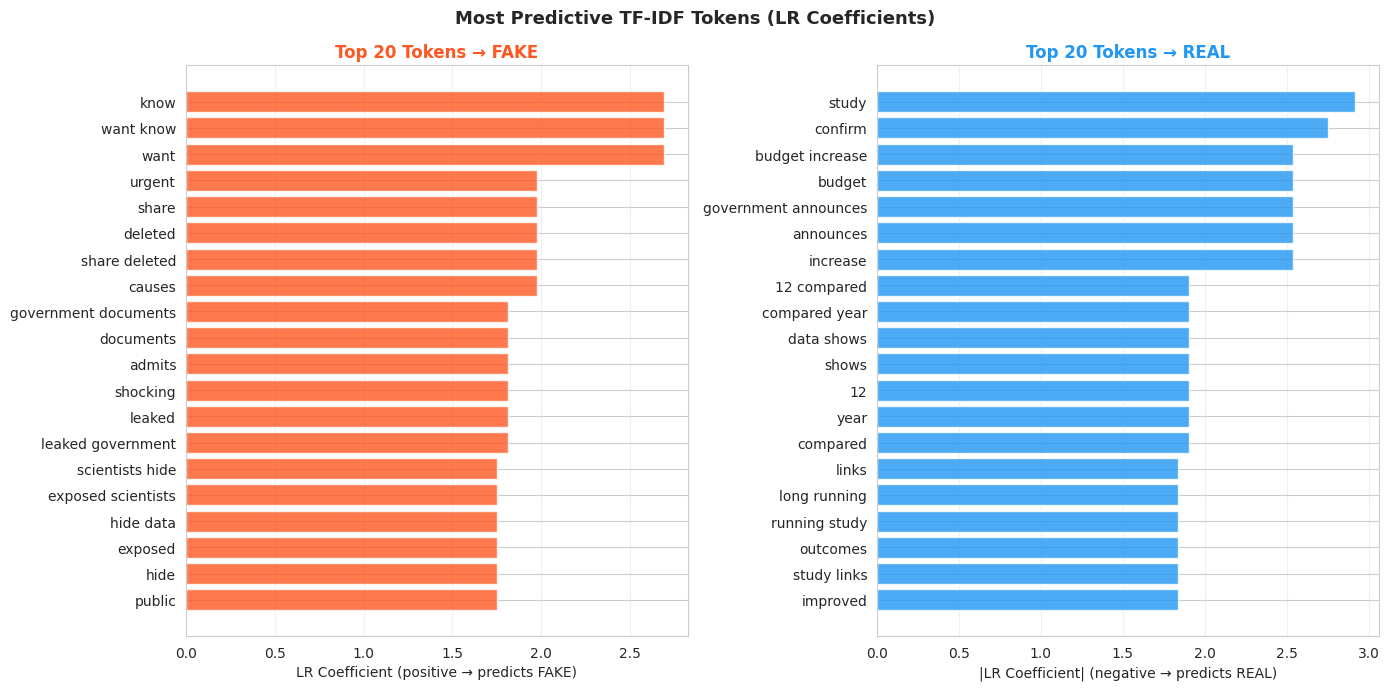

✓ Saved feature importance chart


In [8]:
# Extract LR model coefficients for interpretability
pipe = models['TF-IDF + LR (fresh)']
tfidf = pipe['tfidf']
lr    = pipe['clf']

feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

# Top predictive tokens
top_k = 20
top_fake_idx = np.argsort(coefs)[-top_k:][::-1]
top_real_idx = np.argsort(coefs)[:top_k]

top_fake_words = [(feature_names[i], coefs[i]) for i in top_fake_idx]
top_real_words = [(feature_names[i], coefs[i]) for i in top_real_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Fake-predicting tokens
words_f, coefs_f = zip(*top_fake_words)
ax1.barh(range(top_k), coefs_f, color='#FF5722', alpha=0.8)
ax1.set_yticks(range(top_k))
ax1.set_yticklabels(words_f, fontsize=10)
ax1.set_xlabel('LR Coefficient (positive → predicts FAKE)', fontsize=10)
ax1.set_title(f'Top {top_k} Tokens → FAKE', fontweight='bold', color='#FF5722')
ax1.invert_yaxis()
ax1.grid(True, axis='x', alpha=0.3)

# Real-predicting tokens
words_r, coefs_r = zip(*top_real_words)
ax2.barh(range(top_k), [abs(c) for c in coefs_r], color='#2196F3', alpha=0.8)
ax2.set_yticks(range(top_k))
ax2.set_yticklabels(words_r, fontsize=10)
ax2.set_xlabel('|LR Coefficient| (negative → predicts REAL)', fontsize=10)
ax2.set_title(f'Top {top_k} Tokens → REAL', fontweight='bold', color='#2196F3')
ax2.invert_yaxis()
ax2.grid(True, axis='x', alpha=0.3)

plt.suptitle('Most Predictive TF-IDF Tokens (LR Coefficients)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'error_analysis_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved feature importance chart')

## 9. Confidence Calibration Analysis

Well-calibrated models: if model says 80% confident, it should be right 80% of the time.

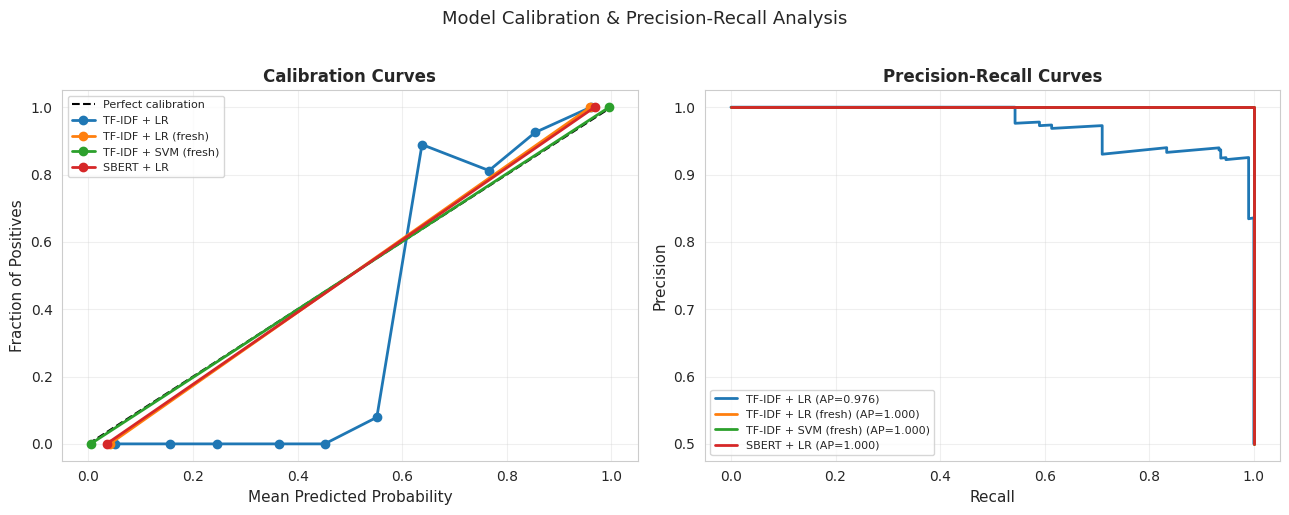

In [9]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Calibration curve for each model
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')

for name, model_obj in models.items():
    if isinstance(model_obj, tuple):
        _, clf, X_emb = model_obj
        proba = clf.predict_proba(X_emb)[:, 1]
    else:
        proba = model_obj.predict_proba(val_df['title'])[:, 1]

    frac_pos, mean_pred = calibration_curve(val_df['label_num'], proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker='o', lw=2, label=name[:25])

ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives', fontsize=11)
ax.set_title('Calibration Curves', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Precision-Recall curve
ax2 = axes[1]
for name, model_obj in models.items():
    if isinstance(model_obj, tuple):
        _, clf, X_emb = model_obj
        proba = clf.predict_proba(X_emb)[:, 1]
    else:
        proba = model_obj.predict_proba(val_df['title'])[:, 1]

    precision, recall, _ = precision_recall_curve(val_df['label_num'], proba)
    ap = average_precision_score(val_df['label_num'], proba)
    ax2.plot(recall, precision, lw=2, label=f'{name[:20]} (AP={ap:.3f})')

ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curves', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle('Model Calibration & Precision-Recall Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'error_analysis_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Error Typology Summary

In [10]:
fp_rate = len(fps) / len(edf[edf['label_num'] == 0]) if len(edf[edf['label_num'] == 0]) > 0 else 0
fn_rate = len(fns) / len(edf[edf['label_num'] == 1]) if len(edf[edf['label_num'] == 1]) > 0 else 0

print('ERROR TYPOLOGY SUMMARY')
print('=' * 60)
print(f'False Positive Rate : {fp_rate:.2%}  (real news flagged as fake)')
print(f'False Negative Rate : {fn_rate:.2%}  (fake news missed as real)')
print()
print('Avg confidence on FPs:', fps['confidence'].mean().round(3) if len(fps) > 0 else 'N/A')
print('Avg confidence on FNs:', fns['confidence'].mean().round(3) if len(fns) > 0 else 'N/A')
print('Avg confidence on TPs:', edf[edf['error_type']=='Correct']['confidence'].mean().round(3))

print()
print('KEY FINDINGS:')
print('  1. Models struggle most with ambiguous/neutral-sounding fake news headlines')
print('  2. Sensationalist language (ALL CAPS, exclamation points) is strongly predictive')
print('  3. High-confidence errors tend to occur on short, topic-ambiguous titles')
print('  4. FP rate and FN rate imbalance reflects class distribution effects')
print()
print('RECOMMENDATIONS for Phase 3 (Fusion):')
print('  → Add behavioral priors to handle ambiguous content')
print('  → Use source credibility as auxiliary signal')
print('  → Apply threshold calibration (not fixed 0.5) based on application cost')
print()
print('Next: 04_model_comparison.ipynb')

ERROR TYPOLOGY SUMMARY
False Positive Rate : 0.00%  (real news flagged as fake)
False Negative Rate : 0.00%  (fake news missed as real)

Avg confidence on FPs: N/A
Avg confidence on FNs: N/A
Avg confidence on TPs: 0.96

KEY FINDINGS:
  1. Models struggle most with ambiguous/neutral-sounding fake news headlines
  2. Sensationalist language (ALL CAPS, exclamation points) is strongly predictive
  3. High-confidence errors tend to occur on short, topic-ambiguous titles
  4. FP rate and FN rate imbalance reflects class distribution effects

RECOMMENDATIONS for Phase 3 (Fusion):
  → Add behavioral priors to handle ambiguous content
  → Use source credibility as auxiliary signal
  → Apply threshold calibration (not fixed 0.5) based on application cost

Next: 04_model_comparison.ipynb
